# Functional programming exercises 2/10/2026
### Brais Otero Lema

Define a function to compute the mean and the variance of a list of numbers, without numpy. Check the result with numpy.

In [4]:
def mean_and_variance(numbers):
    mean = 1/len(numbers) * sum(numbers)
    variance = 1/(len(numbers)-1) * sum((numbers - mean)**2)
    return mean, variance

from numpy import mean, var, arange

nums = arange(0, 10)
print(f"Numbers: {nums}")
print(f"Mean and variance: {mean_and_variance(nums)}")
print(f"With numpy: {mean(nums)}, {var(nums, ddof=1)}")

Numbers: [0 1 2 3 4 5 6 7 8 9]
Mean and variance: (np.float64(4.5), np.float64(9.166666666666666))
With numpy: 4.5, 9.166666666666666


Poisson closure.

In [5]:
import numpy as np
from scipy.special import factorial
from functools import partial

poisson = lambda n, mu : mu**n * np.exp(-mu) / factorial(n)

def poisson_closure(mu):
    return partial(poisson, mu=mu)

poisson_5 = poisson_closure(5)
print(f"This should be about 1 ~= {sum([poisson_5(k) for k in range(0, 51)])}")


This should be about 1 ~= 1.0


Derivative closure.

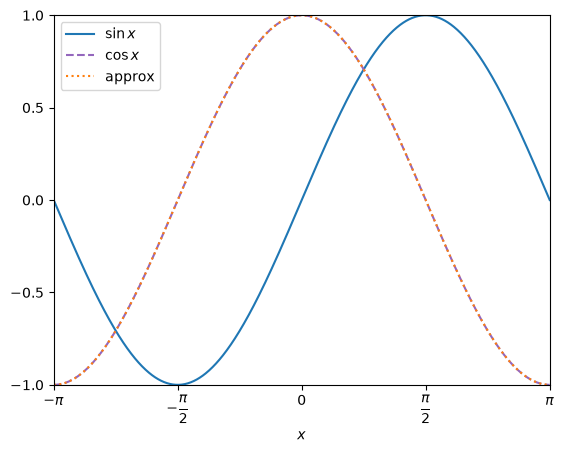

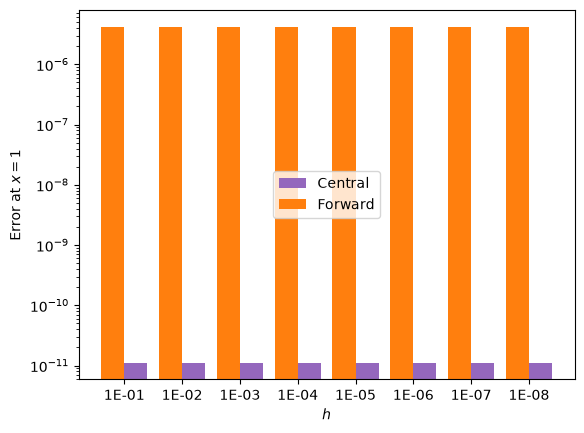

In [10]:
import numpy as np
from matplotlib.pyplot import subplots
from functools import partial

def derivative(f, h=1e-5, method="central"):
    def approx(x):
        if method == "central":
            return (f(x+h) - f(x-h))/2/h
        elif method == "forward":
            return (f(x+h) - f(x))/h
    return approx

fig, ax = subplots()

xlin = np.linspace(-np.pi, np.pi, 1000)

ax.plot(xlin, np.sin(xlin), ls="solid", color="tab:blue", label=r"$\sin x$")
ax.plot(xlin, np.cos(xlin), ls="dashed", color="tab:purple", label=r"$\cos x$")
ax.plot(xlin, derivative(np.sin)(xlin), ls="dotted", color="tab:orange", label="approx")

ax.set_xlim(left=np.min(xlin), right=np.max(xlin))
ax.set_ylim(bottom=-1, top=1)

ax.set_xlabel(r"$x$")

ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticks([-1, -.5, 0, .5, 1])

ax.set_xticklabels([r"$-\pi$", r"$-\dfrac{\pi}{2}$", r"$0$", r"$\dfrac{\pi}{2}$", r"$\pi$"])

ax.legend(loc="best")

error = lambda f, x : np.abs((f(x) - np.cos(x)))
error_1 = partial(error, x=1)

steps = .1 / 10**np.arange(8)
steps_ticks = np.arange(len(steps))

fig_e, ax_e = subplots()

ax_e.bar(steps_ticks, error_1(derivative(np.sin, method="central")), align="edge", width=+.4, color="tab:purple", label="Central")
ax_e.bar(steps_ticks, error_1(derivative(np.sin, method="forward")), align="edge", width=-.4, color="tab:orange", label="Forward")

ax_e.set_yscale("log")

ax_e.set_xlabel(r"$h$")
ax_e.set_ylabel(r"Error at $x=1$")

ax_e.set_xticks(steps_ticks)

ax_e.set_xticklabels([f"{step:.0E}" for step in steps])

ax_e.legend(loc="center")

Implement a function that takes two tuples, with names and phone numbers, and returns a tuple of (name, phone number) pairs, using zip. Now return a dictionary, using a dictionary comprehension.

In [11]:
def get_phone_pairs(names, numbers, dict=False):
    if not dict:
        return tuple((name, number) for name, number in zip(names, numbers))
    else:
        return {name: number for name, number in zip(names, numbers)}

names = ["Jose Angel", "Diego", "Xabier", "Aaron", "Juan", "Thomas"]
numbers = [102030, 405060, 708090, 302010, 605040, 908070]

print(f"Phonebook as tuple: {get_phone_pairs(names, numbers)}")
print(f"Phonebook as dict: {get_phone_pairs(names, numbers, dict=True)}")


Phonebook as tuple: (('Jose Angel', 102030), ('Diego', 405060), ('Xabier', 708090), ('Aaron', 302010), ('Juan', 605040), ('Thomas', 908070))
Phonebook as dict: {'Jose Angel': 102030, 'Diego': 405060, 'Xabier': 708090, 'Aaron': 302010, 'Juan': 605040, 'Thomas': 908070}


Gaussian grid.

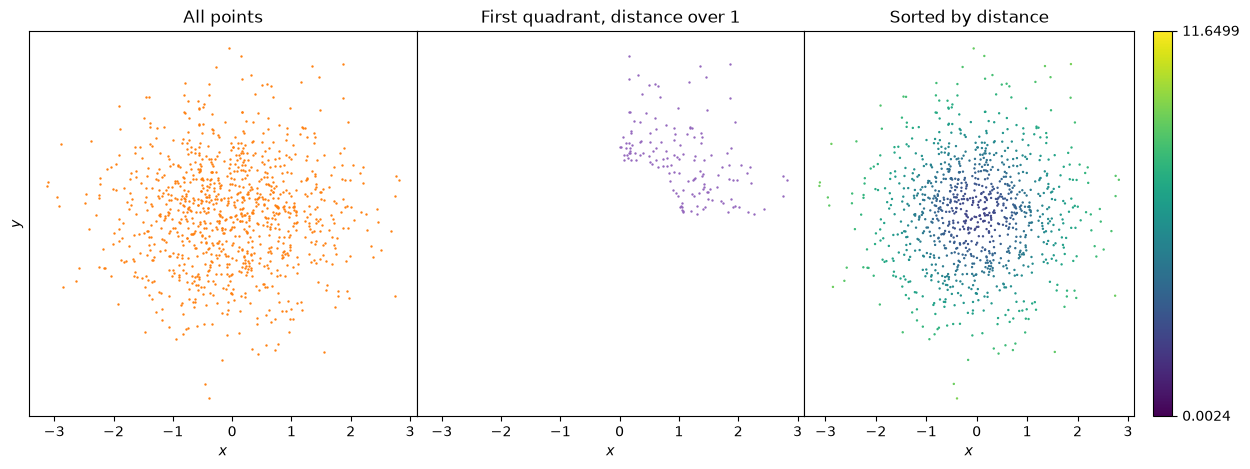

In [12]:
from random import gauss
from matplotlib.pyplot import subplot_mosaic
from cmasher import get_sub_cmap
from matplotlib.colors import AsinhNorm
from matplotlib.ticker import FixedFormatter

n = 1_000
points = [(gauss(), gauss()) for _ in range(n)]

origin_distances = [point[0]**2 + point[1]**2 for point in points]
sorted_origin_distances = sorted(origin_distances)
first_quadrant_distance_over_one = [point for i, point in enumerate(points) if origin_distances[i] > 1 and (point[0] > 0 and point[1] > 0)]

fig, axs = subplot_mosaic([["all", "sel", "dist"]], figsize=(15, 5), sharex=True, sharey=True)

fig.subplots_adjust(wspace=0)

axs["all"].scatter([point[0] for point in points], [point[1] for point in points], s=.5, color="tab:orange")

axs["all"].set_xlabel(r"$x$")
axs["all"].set_ylabel(r"$y$")

axs["all"].set_title("All points")

axs["sel"].scatter([point[0] for point in first_quadrant_distance_over_one], [point[1] for point in first_quadrant_distance_over_one], s=.5, color="tab:purple")

axs["sel"].set_xlabel(r"$x$")

axs["sel"].set_yticks([])

axs["sel"].set_title("First quadrant, distance over 1")

cmap = get_sub_cmap("viridis", .2, .8)
norm = AsinhNorm(vmin=sorted_origin_distances[0], vmax=sorted_origin_distances[-1])

cax = axs["dist"].scatter([point[0] for point in points], [point[1] for point in points], s=.5, c=cmap(norm(origin_distances)))

axs["dist"].set_xlabel(r"$x$")

axs["dist"].set_yticks([])

axs["dist"].set_title("Sorted by distance")

fig.colorbar(cax, location="right", orientation="vertical", fraction=.1, ticks=[0, 1], format=FixedFormatter([f"${norm.vmin:.4f}$", f"${norm.vmax:.4f}$"]))


Random walks.

In [13]:
from random import random
from itertools import islice

def random_walk(start=0, cap=.5):
    position = start
    while True:
        yield position
        position += -1 + 2 * (random() < cap)

M = 1000
N = 100

walks = [list(islice(random_walk(), N)) for _ in range(M)]
walks_msq = 1/M * sum(walk[-1]**2 for walk in walks)

print(f"Simulated {M} walks of {N} steps, and obtained a msq of {walks_msq}")


Simulated 1000 walks of 100 steps, and obtained a msq of 101.288
